# U-Net vs VAE: same encoder–decoder bones, different jobs

**Thesis:** Autoencoders/VAEs learn to **reconstruct** images; U-Nets learn to **segment** them. The architectures rhyme, but the **head, loss, and supervision** differ—so do the outcomes.

## Latent walks (what and why)
A **latent walk** is decoding a smooth path between two latent codes.
- Pick two codes \(z_0, z_1\) (e.g., encodings of two images).
- Interpolate \(z(t) = (1-t)z_0 + t z_1\) for \(t \in [0,1]\) (or use slerp).
- Decode each \(z(t)\) to an image.
**Why it matters:** Good VAEs map images to a **continuous manifold**, so small moves in \(z\) produce small, meaningful visual changes (pose, color, style). It’s a sanity check that the model learned a structured latent space rather than memorizing pixels.

## Why segmentation?
If we want the model to “know the pet,” we want a **per-pixel mask** of the subject, not the whole background. The mask is the **ground truth (GT)**: white = foreground, black = background.

## Why U-Net?
U-Net adds **skip connections**: it passes high-resolution encoder features directly to the decoder at the same scale (concatenate, then convolve). This recovers edges lost during downsampling, yielding **sharper boundaries** and higher overlap metrics (IoU/Dice).

## What we’ll demo (Oxford-IIIT Pet, binary masks)

### 1) Reconstruction track
- **Models:** `ConvAE`, `ConvVAE`
- **How:** train to minimize pixel reconstruction loss (BCE-with-logits). Show recon grids and a latent walk.
- **What you’ll learn (why this demo):**
  - VAEs produce **smoother, more coherent** reconstructions than AEs.
  - Latent space is **continuous**: interpolations change images smoothly.
  - Reconstruction ≠ understanding of object boundaries.


#### Auto-Encoder (AE)

Image x ──▶ [ Encoder f(ϕ) ] ──▶ [  z  ] ──▶ [ Decoder g(θ) ] ──▶ x_hat
              (downsample)         (latent)      (upsample)

(reconstruction loss: compare x_hat vs x)


#### Variational Auto-Encoder (VAE) - reconstruction + KL

Image x ──▶ [ Encoder f(ϕ) ] ──▶  μ(x)
                           └──▶  logσ²(x) ──▶ σ = exp(0.5·logσ²)

μ(x) ──▶
        └──▶ [ reparameterize: z = μ + σ·ε ] ──▶ [ Decoder g(θ) ] ──▶ x_hat
σ     ──▶

(reconstruction loss: x_hat vs x)   (+ KL(q(z|x) || p(z)=N(0,I)) regularization)


### 2) Segmentation track
- **Models:** `UNetSeg` vs `UNetNoSkipSeg` (same capacity; the only change is **skips**)
- **How:** train with overlap-aware loss (BCE-with-logits + Dice). Evaluate IoU at 0.5 and at the **best threshold** found on validation.
- **What you’ll learn (why this demo):**
  - **Skips matter:** U-Net predicts **crisper masks** and preserves thin p


#### U-Net with skip connections disabled
Image x ──▶ [ Encoder f(ϕ) ] ──▶  μ(x)
                           └──▶  logσ²(x) ──▶ σ = exp(0.5·logσ²)

μ(x) ──▶
        └──▶ [ reparameterize: z = μ + σ·ε ] ──▶ [ Decoder g(θ) ] ──▶ x_hat
σ     ──▶

(reconstruction loss: x_hat vs x)   (+ KL(q(z|x) || p(z)=N(0,I)) regularization)


#### U-Net (with skip connections) — segmentation

Image x ──▶ [ Encoder ] ──▶ [ Bottleneck ] ──▶ [ Decoder ] ──▶ [ Head 1×1 ] ──▶  Mask  (sigmoid)

**Down path**:  H → H/2 → H/4 </br>
**Bottleneck**: @ H/8 (no sampling) </br>
**Up path**:    H/4 → H/2 → H </br>
**Skips**: encoder features at H, H/2, H/4 → concat into decoder at matching scales </br>
**Loss**:  BCE-with-logits + Dice (Mask vs GT)


In [20]:
import os
from contextlib import contextmanager
import torch

HOME_DIR = f"{os.environ['HOME']}/Documents/GitHub/Generative-AI"
project = "UNet_v_VAE"
dataset_path = f"{HOME_DIR}/datasets/{project}"
result_path = f"{HOME_DIR}/results/{project}"
import sys
sys.path += [dataset_path, result_path]

# Determine the GPU type (cuda for Nvidia, mps for Mac, cpu if neither available)
from support import get_device
device = get_device()

# Depending on the GPU device, select the appropriate precision to ensure accuracy and reduce memory usage
@contextmanager
def smart_autocast(device: torch.device, enabled=True):
    if not enabled:
        yield
    elif device.type == "cuda":
        with torch.autocast(device_type="cuda", dtype=torch.float16):
            yield
    elif device.type == "mps":
        # MPS AMP exists; BF16 is safest. If you see weirdness, set enabled=False.
        with torch.autocast(device_type="mps", dtype=torch.bfloat16):
            yield
    else:
        yield  # CPU: no autocast


### Helpers - for evaluation / understanding
These helpers compare the performance of various NN architectures through visualizations:
<ul><li>Convolutional Auto-Encoder</li>
<li>Convolutional Variational Auto-Encoder (AE with regularization)</li>
<li>U-Net: similar to a VAE with 'skip' operation from encoder to decoder side</li>
<li>U-Net "no-skip": a U-Net with the 'skip' disabled</li></ul>
They also compare effects of key parameters:<ul>
<li>Latent encodings on a VAE for segmentation quality</li>
<li>Selection threshold (0-1) effect on how well an image is segmented from the background (IoU)</li></ul>

In [21]:
import torch, matplotlib.pyplot as plt

@torch.no_grad()
def save_unet_progress(unet_model, loader, device, path="unet_progress.png", thr=0.5, n=4):
    '''UNet learning over time. Sharpening boundaries and shrinking error'''
    unet_model.eval()
    x, y = next(iter(loader))
    x, y = x.to(device), y.to(device)
    p = torch.sigmoid(unet_model(x))
    m = (p > thr).float()
    err = (p - y).abs()  # probability error map

    x, y, m, err = x[:n].cpu(), y[:n].cpu(), m[:n].cpu(), err[:n].cpu()

    rows, cols = 4, n
    fig = plt.figure(figsize=(3*cols, 3*rows))
    for i in range(n):
        # row 1: input
        ax = fig.add_subplot(rows, cols, 1+i); ax.axis("off")
        img = x[i] if x.shape[1]==3 else x[i].repeat(3,1,1)
        ax.set_title("Input" if i==0 else "")
        ax.imshow(img.permute(1,2,0).numpy())
        # row 2: GT
        ax = fig.add_subplot(rows, cols, 1*cols+i+1); ax.axis("off")
        ax.set_title("GT" if i==0 else "")
        ax.imshow(y[i,0].numpy(), cmap="gray")
        # row 3: Pred
        ax = fig.add_subplot(rows, cols, 2*cols+i+1); ax.axis("off")
        ax.set_title(f"Pred@{thr:.2f}" if i==0 else "")
        ax.imshow(m[i,0].numpy(), cmap="gray")
        # row 4: |prob − GT|
        ax = fig.add_subplot(rows, cols, 3*cols+i+1); ax.axis("off")
        ax.set_title("|prob − GT|" if i==0 else "")
        ax.imshow(err[i,0].numpy(), cmap="gray", vmin=0, vmax=1)
    fig.tight_layout(); fig.savefig(path, dpi=160); plt.close(fig)

@torch.no_grad()
def save_noskip_vs_unet(noskip_model, unet_model, loader, device, path="noskip_vs_unet.png", thr=0.5, n=4):
    '''Architecture payoff of using U-Net vs the 'no-skip' of AE/VAE '''
    noskip_model.eval(); unet_model.eval()
    x, y = next(iter(loader))
    x, y = x.to(device), y.to(device)
    p0 = torch.sigmoid(noskip_model(x))
    p1 = torch.sigmoid(unet_model(x))
    m0 = (p0 > thr).float()
    m1 = (p1 > thr).float()
    x, y, m0, m1 = x[:n].cpu(), y[:n].cpu(), m0[:n].cpu(), m1[:n].cpu()

    rows, cols = 4, n
    fig = plt.figure(figsize=(3*cols, 3*rows))
    for i in range(n):
        ax = fig.add_subplot(rows, cols, 1+i); ax.axis("off")
        img = x[i] if x.shape[1]==3 else x[i].repeat(3,1,1)
        ax.set_title("Input" if i==0 else ""); ax.imshow(img.permute(1,2,0).numpy())
        ax = fig.add_subplot(rows, cols, 1*cols+i+1); ax.axis("off")
        ax.set_title("GT" if i==0 else ""); ax.imshow(y[i,0].numpy(), cmap="gray")
        ax = fig.add_subplot(rows, cols, 2*cols+i+1); ax.axis("off")
        ax.set_title("No-skip pred" if i==0 else ""); ax.imshow(m0[i,0].numpy(), cmap="gray")
        ax = fig.add_subplot(rows, cols, 3*cols+i+1); ax.axis("off")
        ax.set_title("U-Net pred" if i==0 else ""); ax.imshow(m1[i,0].numpy(), cmap="gray")
    fig.tight_layout(); fig.savefig(path, dpi=160); plt.close(fig)


In [22]:
@torch.no_grad()
def save_threshold_curve(unet_model, loader, device, path="iou_vs_threshold.png"):
    unet_model.eval()
    xs, ys = [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        prob = torch.sigmoid(unet_model(x))
        xs.append(prob.cpu()); ys.append(y.cpu())
        break  # one batch is fine for the picture
    prob = torch.cat(xs, 0); y = torch.cat(ys, 0)

    thrs = [i/100 for i in range(1,100)]
    scores = []
    for t in thrs:
        pred = (prob > t).float()
        inter = (pred*y).sum((1,2,3))
        union = (pred + y - pred*y).sum((1,2,3)).clamp_min(1)
        scores.append((inter/union).mean().item())

    import matplotlib.pyplot as plt
    plt.figure(figsize=(6,4))
    plt.plot(thrs, scores)
    plt.xlabel("Threshold"); plt.ylabel("IoU"); plt.title("IoU vs Threshold")
    plt.tight_layout(); plt.savefig(path, dpi=160); plt.close()


In [23]:
torch.no_grad()
def save_vae_recons(vae_or_ae_model, loader, device, path= result_path + "/vae_recon.png", n=4):
    import matplotlib.pyplot as plt
    vae_or_ae_model.eval()
    xb, _ = next(iter(loader))
    xb = xb.to(device)

    out = vae_or_ae_model(xb)
    xhat_logits = out[0] if isinstance(out, tuple) else out

    x_vis    = xb.detach().cpu().clamp(0, 1)
    xhat_vis = torch.sigmoid(xhat_logits).detach().cpu().clamp(0, 1)

    k = min(n, x_vis.shape[0])  # <-- cap to batch size

    rows, cols = 2, k
    fig = plt.figure(figsize=(3*cols, 3*rows))
    for i in range(k):
        ax = fig.add_subplot(rows, cols, 1+i); ax.axis("off")
        img = x_vis[i] if x_vis.shape[1]==3 else x_vis[i].repeat(3,1,1)
        ax.set_title("Input" if i==0 else ""); ax.imshow(img.permute(1,2,0).numpy())

        ax = fig.add_subplot(rows, cols, cols+i+1); ax.axis("off")
        img = xhat_vis[i] if xhat_vis.shape[1]==3 else xhat_vis[i].repeat(3,1,1)
        ax.set_title("Recon (sigmoid)" if i==0 else ""); ax.imshow(img.permute(1,2,0).numpy())

    fig.tight_layout(); fig.savefig(path, dpi=160); plt.close(fig)

@torch.no_grad()
def save_vae_latent_walk(conv_vae_model, loader, device, steps=8, path=result_path + "/vae_latent_walk.png"):
    import matplotlib.pyplot as plt
    conv_vae_model.eval()
    xb, _ = next(iter(loader))
    xb = xb.to(device)
    xb = xb[:1]  # we only need one seed image

    _, mu, logvar = conv_vae_model(xb)
    std = torch.exp(0.5 * logvar)
    z0, z1 = mu, mu + std

    imgs = []
    for i in range(steps):
        z = z0 + (z1 - z0) * (i / (steps - 1))
        h = conv_vae_model.latent_to_feat(z)
        h = conv_vae_model.u3(h); h = conv_vae_model.u2(h); h = conv_vae_model.u1(h)
        out_logits = conv_vae_model.head(h)
        out_vis = torch.sigmoid(out_logits).squeeze(0).detach().cpu().clamp(0,1)
        imgs.append(out_vis)

    fig = plt.figure(figsize=(3*steps, 3))
    for i, im in enumerate(imgs):
        ax = fig.add_subplot(1, steps, i+1); ax.axis("off")
        img = im if im.shape[0]==3 else im.repeat(3,1,1)
        ax.imshow(img.permute(1,2,0).numpy())
        if i==0: ax.set_title("z0")
        if i==steps-1: ax.set_title("z1")
    fig.tight_layout(); fig.savefig(path, dpi=160); plt.close(fig)



In [24]:
import torch, math
import matplotlib.pyplot as plt

@torch.no_grad()
def save_summary_sheet(
    convae_model, convvae_model, unet_model, noskip_model,
    loader, device, path="summary_sheet.png", thr=0.5, n=4
):
    """
    Make a grid with columns:
      [Input | AE recon | VAE recon | GT | U-Net pred | No-skip pred]
    using the SAME n images from the first batch of `loader`.

    Assumptions:
      - Models output logits for seg (U-Net / No-skip), need sigmoid.
      - AE/VAE decoders output [0,1] (sigmoid) or raw in [0,1].
      - Images are floats in [0,1]. If you normalized, denorm before showing.
    """
    # switch to eval, remember state
    models = [convae_model, convvae_model, unet_model, noskip_model]
    was_training = [m.training for m in models]
    for m in models: m.eval()

    # fixed batch
    xb, yb = next(iter(loader))
    xb, yb = xb.to(device), yb.to(device)
    n = min(n, xb.size(0))

    # --- AE / VAE reconstructions ---
    # ConvAE: x -> x_hat
    ae_recon = convae_model(xb[:n]).clamp(0,1)

    # ConvVAE: x -> (x_hat, mu, logvar) or just x_hat depending on your forward
    vae_out = convvae_model(xb[:n])
    if isinstance(vae_out, (list, tuple)) and len(vae_out) >= 1:
        vae_recon = vae_out[0]
    else:
        vae_recon = vae_out
    vae_recon = vae_recon.clamp(0,1)

    # --- Segmentation preds (logits -> prob -> mask) ---
    unet_prob   = torch.sigmoid(unet_model(xb[:n]))
    noskip_prob = torch.sigmoid(noskip_model(xb[:n]))
    unet_pred   = (unet_prob   > thr).float()
    noskip_pred = (noskip_prob > thr).float()

    # --- helpers for visualization ---
    def to_disp(img):  # (C,H,W) -> (H,W,3) CPU numpy
        img = img.detach().float().cpu()
        if img.ndim == 3:
            if img.shape[0] == 1:
                img = img.repeat(3,1,1)
            elif img.shape[0] > 3:
                img = img[:3]  # just in case
            return img.permute(1,2,0).clamp(0,1).numpy()
        raise ValueError("Expected CHW image tensor")

    def to_mask(mask):  # (1,H,W) -> (H,W) grayscale
        m = mask.detach().float().cpu()
        if m.ndim == 3 and m.shape[0] == 1:
            m = m[0]
        return m.clamp(0,1).numpy()

    # --- build figure ---
    titles = ["Input", "AE recon", "VAE recon", "GT", "UNet pred", "No-skip pred"]
    cols = len(titles)
    rows = n
    h = max(2.2 * rows, 3.0)
    w = max(2.8 * cols, 8.0)
    fig = plt.figure(figsize=(w, h), dpi=150)

    for i in range(n):
        # column 1: input
        ax = fig.add_subplot(rows, cols, i*cols + 1); ax.axis("off")
        ax.imshow(to_disp(xb[i]))
        if i == 0: ax.set_title(titles[0], fontsize=10)

        # column 2: AE recon
        ax = fig.add_subplot(rows, cols, i*cols + 2); ax.axis("off")
        ax.imshow(to_disp(ae_recon[i]))
        if i == 0: ax.set_title(titles[1], fontsize=10)

        # column 3: VAE recon
        ax = fig.add_subplot(rows, cols, i*cols + 3); ax.axis("off")
        ax.imshow(to_disp(vae_recon[i]))
        if i == 0: ax.set_title(titles[2], fontsize=10)

        # column 4: GT mask
        ax = fig.add_subplot(rows, cols, i*cols + 4); ax.axis("off")
        ax.imshow(to_mask(yb[i]), cmap="gray")
        if i == 0: ax.set_title(titles[3], fontsize=10)

        # column 5: UNet pred
        ax = fig.add_subplot(rows, cols, i*cols + 5); ax.axis("off")
        ax.imshow(to_mask(unet_pred[i]), cmap="gray")
        if i == 0: ax.set_title(titles[4] + f" @ {thr:.2f}", fontsize=10)

        # column 6: No-skip pred
        ax = fig.add_subplot(rows, cols, i*cols + 6); ax.axis("off")
        ax.imshow(to_mask(noskip_pred[i]), cmap="gray")
        if i == 0: ax.set_title(titles[5] + f" @ {thr:.2f}", fontsize=10)

    plt.tight_layout()
    fig.savefig(path, bbox_inches="tight")
    plt.close(fig)

    # restore train/eval states
    for m, was in zip(models, was_training):
        if was: m.train()



### Model Building blocks
We want to demonstrate this using the same basic blocks for either architecture

| Block          | U-Net (seg)            | ConvVAE (recon)                |
| -------------- | ---------------------- | ------------------------------ |
| DoubleConv     | ✅ encoder + decoder    | ✅ encoder + decoder            |
| Down           | ✅                      | ✅                              |
| Up             | ✅ + **concat skip**    | ✅ **no skip**                  |
| OutHead        | ✅ → `n_classes` logits | ✅ → `in_ch` logits             |
| μ / logσ       | —                      | ✅ 1×1 conv heads               |
| latent_to_feat | —                      | ✅ 1×1 conv to decoder channels |


In [25]:
import torch, torch.nn as nn, torch.nn.functional as F

import torch
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch, groups=8):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.GroupNorm(groups, out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.GroupNorm(groups, out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x): 
        return self.block(x)

class UpUNet(nn.Module):
    def __init__(self, up_ch, skip_ch, out_ch, groups=8):
        """
        up_ch:  channels coming from the lower (bottleneck) path BEFORE concat (after upsample)
        skip_ch: channels from the encoder skip at the matching scale
        out_ch: channels to produce after the DoubleConv
        """
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        # IMPORTANT: avoid attribute name 'double' to not clash with nn.Module.double()
        self.conv_block = DoubleConv(up_ch + skip_ch, out_ch, groups=groups)

    def forward(self, x, skip):
        x = self.up(x)
        # align spatial dims (off-by-1 safe)
        dh = skip.size(2) - x.size(2)
        dw = skip.size(3) - x.size(3)
        if dh or dw:
            x = F.pad(x, (0, max(0, dw), 0, max(0, dh)))
            x = x[:, :, :skip.size(2), :skip.size(3)]
        x = torch.cat([x, skip], dim=1)
        return self.conv_block(x)

# --------- Down block: maxpool then DoubleConv ----------
class Down(nn.Module):
    def __init__(self, c_in, c_out):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.conv = DoubleConv(c_in, c_out)
    def forward(self, x):
        return self.conv(self.pool(x))


# --- No skip (for ConvAE / ConvVAE) ---
class UpNoSkip(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.block = DoubleConv(in_ch, out_ch)
    def forward(self, x):
        x = self.up(x)
        return self.block(x)
    
# A UNet model w/ "no skip" to show the benefit of the skip operation.
# Head for segmentation (1 logit channel)
class SegHead(nn.Module):
    def __init__(self, in_ch, n_classes=1):
        super().__init__()
        self.out = nn.Conv2d(in_ch, n_classes, kernel_size=1)
    def forward(self, x): return self.out(x)  # logits


### Models

In [26]:
class UNetSeg(nn.Module):
    def __init__(self, in_ch=3, n_classes=1, base=32):
        super().__init__()
        self.enc1 = DoubleConv(in_ch, base)
        self.enc2 = Down(base, base*2)
        self.enc3 = Down(base*2, base*4)
        self.bottleneck = Down(base*4, base*8)

        self.up3 = UpUNet(up_ch=base*8, skip_ch=base*4, out_ch=base*4)
        self.up2 = UpUNet(up_ch=base*4, skip_ch=base*2, out_ch=base*2)
        self.up1 = UpUNet(up_ch=base*2, skip_ch=base,   out_ch=base)

        self.head = nn.Conv2d(base, n_classes, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x); e2 = self.enc2(e1); e3 = self.enc3(e2); b = self.bottleneck(e3)
        d3 = self.up3(b, e3); d2 = self.up2(d3, e2); d1 = self.up1(d2, e1)
        return self.head(d1)  # logits



In [27]:


# No-skip segmentation model (encoder-decoder like ConvAE, but with seg head)
class UNetNoSkipSeg(nn.Module):
    def __init__(self, in_ch=3, base=32):
        super().__init__()
        self.e1 = DoubleConv(in_ch, base)
        self.e2 = Down(base, base*2)
        self.e3 = Down(base*2, base*4)
        self.b  = Down(base*4, base*8)

        self.u3 = UpNoSkip(base*8, base*4)
        self.u2 = UpNoSkip(base*4, base*2)
        self.u1 = UpNoSkip(base*2, base)

        self.head = SegHead(base, n_classes=1)  # logits

    def forward(self, x):
        x = self.e1(x); x = self.e2(x); x = self.e3(x); x = self.b(x)
        x = self.u3(x); x = self.u2(x); x = self.u1(x)
        return self.head(x)  # [B,1,H,W] logits


#### Convolutional Auto-Encoder (Conv AE)

In [28]:
class ConvAE(nn.Module):
    def __init__(self, in_ch=3, base=32):
        super().__init__()
        self.e1 = DoubleConv(in_ch, base)
        self.e2 = Down(base, base*2)
        self.e3 = Down(base*2, base*4)
        self.b  = Down(base*4, base*8)

        self.u3 = UpNoSkip(base*8, base*4)
        self.u2 = UpNoSkip(base*4, base*2)
        self.u1 = UpNoSkip(base*2, base)

        self.head = SegHead(base, in_ch)  # logits (is this right?)

    def forward(self, x):
        x = self.e1(x); x = self.e2(x); x = self.e3(x); x = self.b(x)
        x = self.u3(x); x = self.u2(x); x = self.u1(x)
        return self.head(x)  # logits


#### Convolutional Variational Auto-Encoder (Conv VAE)

In [29]:
class ConvVAE(nn.Module):
    def __init__(self, in_ch=3, z_dim=128, base=32):
        super().__init__()
        self.e1 = DoubleConv(in_ch, base)
        self.e2 = Down(base, base*2)
        self.e3 = Down(base*2, base*4)
        self.b  = Down(base*4, base*8)
        c = base*8
        self.mu     = nn.Conv2d(c, z_dim, 1)
        self.logvar = nn.Conv2d(c, z_dim, 1)

        self.latent_to_feat = nn.Conv2d(z_dim, c, 1)
        self.u3 = UpNoSkip(c, base*4)
        self.u2 = UpNoSkip(base*4, base*2)
        self.u1 = UpNoSkip(base*2, base)
        self.head = SegHead(base, in_ch)  # logits (is this right)

    def reparam(self, mu, logvar):
        std = torch.exp(0.5*logvar); eps = torch.randn_like(std)
        return mu + std*eps

    def forward(self, x):
        h = self.e1(x); h = self.e2(h); h = self.e3(h); h = self.b(h)
        mu, logvar = self.mu(h), self.logvar(h)
        z = self.reparam(mu, logvar)
        h = self.latent_to_feat(z)
        h = self.u3(h); h = self.u2(h); h = self.u1(h)
        xhat_logits = self.head(h)  # logits
        return xhat_logits, mu, logvar



### Load data

#### `OxfordPetsSeg`: what it does
- Thin wrapper around **Oxford-IIIT Pet** that returns images and **binary masks** so we can train a fast U-Net demo.
  - Downloads (if needed), resizes to a fixed size (e.g., 256×256), converts masks to `{0,1}`.
  - Keeps `H` and `W` divisible by 8 so down/upsampling lines up.
- `bin_rule` controls **how original mask IDs become binary**:
  - `non_background`: foreground = any pixel **not** equal to the dominant background ID (simple; may include “border” pixels).
  - `pet_eq_max`: foreground = pixels with the **max** class ID (works on some torchvision variants).
  - `mask_gt_1`: foreground = pixels with ID **> 1** (merges pet + border as one foreground).
- For the cleanest demo: **pet-only** → `foreground = (seg == 1)` (exact ID can vary by torchvision build).


In [30]:
import torchvision as tv, torchvision.transforms as T
import numpy as np
from torch.utils.data import DataLoader, Subset
from PIL import Image
# In your OxfordPetsSeg class:

class OxfordPetsSeg(torch.utils.data.Dataset):
    def __init__(self, root="./data", split="trainval", size=256, rgb=True, bin_rule="non_background", pet_id=1):
        self.ds = tv.datasets.OxfordIIITPet(
            root=root, download=True, target_types=("segmentation",), split=split
        )
        self.size, self.rgb, self.bin_rule = size, rgb, bin_rule
        self.pet_id = pet_id  # <-- NEW: lets you override the pet class id

        self.t_img = T.Compose([T.Resize((size,size)), T.ToTensor()])
        self.t_msk = T.Resize((size,size), interpolation=T.InterpolationMode.NEAREST)

        # Peek a mask to guess background id (mode)
        _, m0 = self.ds[0]
        arr = np.array(m0, dtype=np.int64)
        vals, counts = np.unique(arr, return_counts=True)
        self.background_id = int(vals[np.argmax(counts)])
        print(f"[Pets] ids sample: {vals.tolist()} | bg≈{self.background_id} | bin_rule={self.bin_rule}")

    def to_binary(self, arr: np.ndarray) -> np.ndarray:
        if self.bin_rule == "non_background":
            return (arr != self.background_id).astype(np.float32)
        if self.bin_rule == "pet_eq_max":
            return (arr == arr.max()).astype(np.float32)
        if self.bin_rule == "mask_gt_1":
            return (arr > 1).astype(np.float32)
        # --- NEW: pet-only with configurable id (default 1) ---
        if self.bin_rule == "pet_eq_one":
            return (arr == self.pet_id).astype(np.float32)
        raise ValueError(f"Unknown bin_rule: {self.bin_rule}")

    def __len__(self): return len(self.ds)

    def __getitem__(self, i):
        img, seg = self.ds[i]
        x = self.t_img(img.convert("RGB") if self.rgb else img.convert("L"))
        seg = self.t_msk(seg)
        y = torch.from_numpy(self.to_binary(np.array(seg, dtype=np.int64))).unsqueeze(0)  # [1,H,W], {0,1}
        return x, y


In [31]:
# 1) Datasets with consistent pet-only masks and augmentation for train
import torchvision.transforms as T

train_tf_img = T.Compose([
    T.Resize((256,256)),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(0.2, 0.2, 0.2, 0.05),
    T.RandomAffine(degrees=10, translate=(0.05,0.05), scale=(0.95,1.05), shear=5),
    T.ToTensor(),
])
val_tf_img = T.Compose([T.Resize((256,256)), T.ToTensor()])
tf_msk = T.Resize((256,256), interpolation=T.InterpolationMode.NEAREST)

# In OxfordPetsSeg __init__, pass transforms or add flags to switch
# Ensure to_binary does: return (arr == 1).astype(np.float32)

full = OxfordPetsSeg(size=256, rgb=True, bin_rule="pet_eq_one", pet_id=1)
idx  = torch.randperm(len(full))[:320]   # 256 train + 64 val
train_ds = torch.utils.data.Subset(full, idx[:256].tolist())
val_ds   = torch.utils.data.Subset(full, idx[256:].tolist())

# If class doesn’t accept external transforms, fork a tiny “OxfordPetsSegTrain/Val”
# that uses train_tf_img vs val_tf_img for images, and tf_msk for masks in both.

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=8, shuffle=False, num_workers=0)


[Pets] ids sample: [1, 2, 3] | bg≈2 | bin_rule=pet_eq_one


### Instantiate Models and define optimizer functions

In [32]:
# Instantiate & push to device (float32 is safest on MPS)
# The number of channels depends on the type of training images (e.g. RGB has 3 channels)
x0, _ = next(iter(train_loader))
IN_CH = x0.shape[1]

# Instantiate the model
unet_model  = UNetSeg(in_ch=IN_CH, n_classes=1, base=32).to(device)
unet_noskip_model= UNetNoSkipSeg(in_ch=IN_CH, base=32).to(device)
conv_ae_model     = ConvAE(in_ch=IN_CH, base=32).to(device)
conv_vae_model    = ConvVAE(in_ch=IN_CH, z_dim=128, base=32).to(device)

# Define optimizers
unet_opt = torch.optim.AdamW(unet_model.parameters(), lr=1e-3, weight_decay=1e-4)
unet_noskip_opt  = torch.optim.AdamW(unet_noskip_model.parameters(), lr=1e-3, weight_decay=1e-4)
convae_opt  = torch.optim.AdamW(conv_ae_model.parameters(),  lr=1e-3)
convvae_opt = torch.optim.AdamW(conv_vae_model.parameters(), lr=1e-3)



### Loss Functions: we use IoU, and a combination of Dice loss and BCE-with-logits
---

#### IoU (Intersection over Union)
- Measures **overlap** between predicted mask `P` and ground truth `G`.
- Binary formula:
$$
  \mathrm{IoU} \;=\; \frac{|P \cap G|}{|P \cup G|} \;=\; \frac{\text{TP}}{\text{TP} + \text{FP} + \text{FN}}
$$
- Why use it for segmentation: focuses on **shape overlap** instead of being dominated by easy background pixels.

---

#### Dice loss vs. BCE-with-logits (and why combine them)
- **Dice coefficient** (overlap metric):
$$
  \mathrm{Dice}(p,y) \;=\; \frac{2\sum p\,y + \varepsilon}{\sum p + \sum y + \varepsilon}
  \quad\Rightarrow\quad
  \mathcal{L}_{\text{Dice}} = 1 - \mathrm{Dice}
  $$

  - Great when **foreground is small**; directly optimizes overlap.

- **BCE-with-logits** (`nn.BCEWithLogitsLoss`)
  - Binary cross-entropy computed on **logits** (numerically stable).
  - Trains **calibrated probabilities** at each pixel.

- **Why the combo (BCE + Dice)**
  - BCE makes probabilities honest; Dice pushes **shape overlap** to improve despite class imbalance.
  - In practice, `BCE + Dice` converges faster and yields **sharper masks** than either alone on small, imbalanced sets.


In [33]:
# Logit heads → use BCEWithLogitsLoss (numerically stable)
bce_logits = nn.BCEWithLogitsLoss()


# ConvVAE KL on spatial latents (average so it's scale-invariant)
def kld_loss(mu, logvar):
    # mu/logvar: [B, z_dim, H/8, W/8] (or whatever your downsample factor is)
    return (-0.5 * (1 + logvar - mu.pow(2) - logvar.exp())).mean()


def dice_loss(prob, target, eps=1e-6):
    num = 2 * (prob*target).sum((1,2,3))
    den = (prob+target).sum((1,2,3)) + eps
    return (1 - (num+eps)/den).mean()

def unet_loss(logits, target, w_bce=1.0, w_dice=1.5):
    return w_bce*bce_logits(logits, target) + w_dice*dice_loss(torch.sigmoid(logits), target)


# IoU for logging (binary); use thresholds at 0.5 for demo
def iou_score(prob, target, thr=0.5, eps=1e-7):
    """
    prob: (N,1,H,W) in [0,1]; target: (N,1,H,W) binary {0,1}
    """
    pred = (prob > thr).float()
    inter = (pred * target).sum(dim=(1,2,3))
    union = (pred + target - pred * target).sum(dim=(1,2,3))
    iou = (inter + eps) / (union + eps)
    return iou.mean()

@torch.no_grad()
def best_iou(prob, y):
    best, best_t = 0.0, 0.5
    for t in [i/20 for i in range(1,20)]:  # 0.05..0.95
        pred = (prob > t).float()
        inter = (pred * y).sum((1,2,3))
        union = (pred + y - pred*y).sum((1,2,3)).clamp_min(1)
        iou = (inter/union).mean().item()
        if iou > best:
            best, best_t = iou, t
    return best, best_t


### Train step for AE, VAE, UNet, UNet NoSkip

In [42]:
def train_one_epoch_convae(loader):
    conv_ae_model.train()
    total, total_recon, n = 0.0, 0.0, 0
    for x, _ in loader:
        x = x.to(device)
        convae_opt.zero_grad(set_to_none=True)
        x_hat = conv_ae_model(x)                 # returns reconstruction
        recon = nn.functional.mse_loss(x_hat, x, reduction="mean")  # or BCE, your choice
        loss = recon                            # AE loss = recon only
        loss.backward(); convae_opt.step()

        bs = x.size(0)
        total += loss.item() * bs
        total_recon += recon.item() * bs
        n += bs
    avg = 1.0 / n
    return {"loss": total*avg, "recon": total_recon*avg, "kld": 0.0}


def train_one_epoch_convvae(loader, beta=1.0):
    conv_vae_model.train()
    total, total_recon, total_kld, n = 0.0, 0.0, 0.0, 0
    for x, _ in loader:
        x = x.to(device)
        convvae_opt.zero_grad(set_to_none=True)
        x_hat, mu, logvar = conv_vae_model(x)
        recon = nn.functional.mse_loss(x_hat, x, reduction="mean")   # or BCE
        kld = (-0.5 * (1 + logvar - mu.pow(2) - logvar.exp())).mean()
        loss = recon + beta * kld
        loss.backward(); convvae_opt.step()

        bs = x.size(0); n += bs
        total += loss.item() * bs
        total_recon += recon.item() * bs
        total_kld += kld.item() * bs
    avg = 1.0 / n
    return {"loss": total*avg, "recon": total_recon*avg, "kld": total_kld*avg}


def train_one_epoch_seg(model, loader, optimizer, device, loss_fn):
    model.train()
    total_loss, total_iou, n = 0.0, 0.0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss   = loss_fn(logits, y)
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            prob = torch.sigmoid(logits)
            iou  = iou_score(prob, y, thr=0.5)
            bs   = x.size(0)
            total_loss += loss.item() * bs
            total_iou  += float(iou) * bs
            n += bs
    return {"loss": total_loss/max(n,1), "iou": total_iou/max(n,1)}



#### Evaluate for AE, VAE, UNet, UNet NoSkip

In [43]:


@torch.no_grad()
def eval_convae(loader):
    conv_ae_model.eval()
    total, total_recon, n = 0.0, 0.0, 0
    for x, _ in loader:
        x = x.to(device)
        x_hat = conv_ae_model(x)
        recon = nn.functional.mse_loss(x_hat, x, reduction="mean")
        loss = recon
        bs = x.size(0)
        total += loss.item() * bs
        total_recon += recon.item() * bs
        n += bs
    avg = 1.0 / n
    return {"loss": total*avg, "recon": total_recon*avg, "kld": 0.0}


@torch.no_grad()
def eval_convvae(loader, beta=1.0):
    conv_vae_model.eval()
    total, total_recon, total_kld, n = 0.0, 0.0, 0.0, 0
    for x, _ in loader:
        x = x.to(device)
        x_hat, mu, logvar = conv_vae_model(x)
        recon = nn.functional.mse_loss(x_hat, x, reduction="mean")
        kld = (-0.5 * (1 + logvar - mu.pow(2) - logvar.exp())).mean()
        loss = recon + beta * kld
        bs = x.size(0); n += bs
        total += loss.item() * bs
        total_recon += recon.item() * bs
        total_kld += kld.item() * bs
    avg = 1.0 / n
    return {"loss": total*avg, "recon": total_recon*avg, "kld": total_kld*avg}


@torch.no_grad()
def eval_segmentation(model, loader, device, loss_fn, thresholds=(0.5,), return_curve=False):
    """
    Unified eval for any segmentation model that outputs logits.
    Returns: {
        "loss": float,
        "iou@0.5": float,        # always present
        "best_iou": float,       # max IoU across thresholds
        "best_thr": float,       # threshold that achieved best_iou
        # optional:
        "curve": List[(thr, iou)]
    }
    """
    was_training = model.training
    model.eval()

    total_loss = 0.0
    total_iou_per_thr = {thr: 0.0 for thr in thresholds}
    n = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = loss_fn(logits, y)
        probs = torch.sigmoid(logits)

        bs = x.size(0)
        total_loss += loss.item() * bs
        n += bs

        # accumulate IoU for each threshold
        for thr in thresholds:
            iou = iou_score(probs, y, thr=thr) 
            total_iou_per_thr[thr] += float(iou) * bs

    # restore training state
    if was_training:
        model.train()

    avg_loss = total_loss / max(n, 1)
    avg_iou_per_thr = {thr: (val / max(n, 1)) for thr, val in total_iou_per_thr.items()}

    # canonical keys
    iou_at_05 = avg_iou_per_thr.get(0.5, next(iter(avg_iou_per_thr.values()), 0.0))
    best_thr, best_iou = max(avg_iou_per_thr.items(), key=lambda kv: kv[1])

    out = {
        "loss": avg_loss,
        "iou@0.5": iou_at_05,
        "best_iou": best_iou,
        "best_thr": float(best_thr),
    }
    if return_curve:
        out["curve"] = sorted(avg_iou_per_thr.items())
    return out


def eval_unet(loader):
    return eval_segmentation(unet_model, loader, device, unet_loss, thresholds=(0.3, 0.4, 0.5, 0.6, 0.7))

def eval_unet_noskip(loader):
    return eval_segmentation(unet_noskip_model, loader, device, unet_loss, thresholds=(0.3, 0.4, 0.5, 0.6, 0.7))


### Train

In [36]:
# parameters
num_epochs = 50
beta = 1.0  # β-VAE (set <1.0 to emphasize recon, >1.0 to emphasize disentangling)

def current_lr(optim):
    for g in optim.param_groups:
        return g["lr"]


In [38]:
# Pick in_channels dynamically from a batch
x0, y0 = next(iter(train_loader))
in_channels = x0.shape[1]          # 1 for grayscale, 3 for RGB
unet_model  = UNetSeg(in_ch=in_channels, n_classes=1, base=32).to(device)

opt = torch.optim.AdamW(unet_model.parameters(), lr=1e-3)


In [44]:

# ---------- AE / VAE training ----------
best_ae = float("inf")
best_vae = float("inf")

for epoch in range(1, num_epochs + 1):
    tr_ae  = train_one_epoch_convae(train_loader)                   # expects {'loss': ...}
    va_ae  = eval_convae(val_loader)                                # expects {'loss': ...}

    tr_vae = train_one_epoch_convvae(train_loader, beta=beta)       # expects {'loss','recon','kld'}
    va_vae = eval_convvae(val_loader,     beta=beta)                # expects {'loss','recon','kld'}

    if va_ae["loss"] < best_ae:
        best_ae = va_ae["loss"]
        torch.save(conv_ae_model.state_dict(), "conv_ae_best.pt")

    if va_vae["loss"] < best_vae:
        best_vae = va_vae["loss"]
        torch.save(conv_vae_model.state_dict(), "conv_vae_best.pt")

    if epoch % 10 == 0 or epoch == 1:
        print(f"[ConvAE] ep {epoch:02d} | train {tr_ae['loss']:.4f} "
              f"| recon {tr_ae['recon']:.4f} | kld {tr_ae['kld']:.4f} "
              f"|| val {va_ae['loss']:.4f} (recon {va_ae['recon']:.4f}, kld {va_ae['kld']:.4f})")
        print(f"[ConvVAE] ep {epoch:02d} | train {tr_vae['loss']:.4f} "
              f"| recon {tr_vae['recon']:.4f} | kld {tr_vae['kld']:.4f} "
              f"|| val {va_vae['loss']:.4f} (recon {va_vae['recon']:.4f}, kld {va_vae['kld']:.4f})")





[ConvAE] ep 01 | train 0.1260 | recon 0.1260 | kld 0.0000 || val 0.0374 (recon 0.0374, kld 0.0000)
[ConvVAE] ep 01 | train 0.1092 | recon 0.0843 | kld 0.0249 || val 0.0446 (recon 0.0388, kld 0.0058)
[ConvAE] ep 10 | train 0.0188 | recon 0.0188 | kld 0.0000 || val 0.0218 (recon 0.0218, kld 0.0000)
[ConvVAE] ep 10 | train 0.0257 | recon 0.0212 | kld 0.0045 || val 0.0279 (recon 0.0233, kld 0.0046)
[ConvAE] ep 20 | train 0.0158 | recon 0.0158 | kld 0.0000 || val 0.0180 (recon 0.0180, kld 0.0000)
[ConvVAE] ep 20 | train 0.0234 | recon 0.0187 | kld 0.0047 || val 0.0252 (recon 0.0203, kld 0.0048)
[ConvAE] ep 30 | train 0.0148 | recon 0.0148 | kld 0.0000 || val 0.0157 (recon 0.0157, kld 0.0000)
[ConvVAE] ep 30 | train 0.0233 | recon 0.0186 | kld 0.0048 || val 0.0251 (recon 0.0196, kld 0.0055)
[ConvAE] ep 40 | train 0.0132 | recon 0.0132 | kld 0.0000 || val 0.0151 (recon 0.0151, kld 0.0000)
[ConvVAE] ep 40 | train 0.0224 | recon 0.0177 | kld 0.0047 || val 0.0240 (recon 0.0192, kld 0.0048)
[Conv

In [39]:
# distinct opts/schedulers
opt_unet   = torch.optim.AdamW(unet_model.parameters(),        lr=1e-3, weight_decay=1e-4)
opt_noskip = torch.optim.AdamW(unet_noskip_model.parameters(), lr=1e-3, weight_decay=1e-4)

sch_unet   = torch.optim.lr_scheduler.CosineAnnealingLR(opt_unet,   T_max=num_epochs)
sch_noskip = torch.optim.lr_scheduler.CosineAnnealingLR(opt_noskip, T_max=num_epochs)

best_un, best_ns = -1.0, -1.0
best_ep_un = best_ep_ns = -1

for epoch in range(1, num_epochs+1):
    tr_un = train_one_epoch_seg(unet_model,        train_loader, opt_unet,   device, unet_loss)
    tr_ns = train_one_epoch_seg(unet_noskip_model, train_loader, opt_noskip, device, unet_loss)

    va_un = eval_segmentation(unet_model,        val_loader, device, unet_loss,
                              thresholds=(0.3,0.4,0.5,0.6,0.7))
    va_ns = eval_segmentation(unet_noskip_model, val_loader, device, unet_loss,
                              thresholds=(0.3,0.4,0.5,0.6,0.7))

    # step schedulers *after* training
    sch_unet.step()
    sch_noskip.step()

    score_un = va_un["best_iou"];  score_ns = va_ns["best_iou"]
    if score_un > best_un:
        best_un, best_ep_un = score_un, epoch
        torch.save(unet_model.state_dict(), "unet_best.pt")
    if score_ns > best_ns:
        best_ns, best_ep_ns = score_ns, epoch
        torch.save(unet_noskip_model.state_dict(), "unet_noskip_best.pt")

    if epoch == 1 or epoch % 10 == 0:
        print(f"[UNet]   ep {epoch:03d} | lr {opt_unet.param_groups[0]['lr']:.6f} "
              f"| tr IoU {tr_un['iou']:.3f} | val IoU@0.5 {va_un['iou@0.5']:.3f} "
              f"| best {va_un['best_iou']:.3f} @ thr={va_un['best_thr']:.2f}")
        print(f"[NoSkip] ep {epoch:03d} | lr {opt_noskip.param_groups[0]['lr']:.6f} "
              f"| tr IoU {tr_ns['iou']:.3f} | val IoU@0.5 {va_ns['iou@0.5']:.3f} "
              f"| best {va_ns['best_iou']:.3f} @ thr={va_ns['best_thr']:.2f}")

print(f"Best UNet     val IoU {best_un:.3f} @ epoch {best_ep_un}")
print(f"Best No-Skip  val IoU {best_ns:.3f} @ epoch {best_ep_ns}")


[UNet]   ep 001 | lr 0.000999 | tr IoU 0.260 | val IoU@0.5 0.426 | best 0.426 @ thr=0.50
[NoSkip] ep 001 | lr 0.000999 | tr IoU 0.220 | val IoU@0.5 0.380 | best 0.395 @ thr=0.40
[UNet]   ep 010 | lr 0.000905 | tr IoU 0.476 | val IoU@0.5 0.457 | best 0.467 @ thr=0.30
[NoSkip] ep 010 | lr 0.000905 | tr IoU 0.498 | val IoU@0.5 0.425 | best 0.447 @ thr=0.30
[UNet]   ep 020 | lr 0.000655 | tr IoU 0.522 | val IoU@0.5 0.496 | best 0.501 @ thr=0.40
[NoSkip] ep 020 | lr 0.000655 | tr IoU 0.541 | val IoU@0.5 0.524 | best 0.524 @ thr=0.50
[UNet]   ep 030 | lr 0.000345 | tr IoU 0.576 | val IoU@0.5 0.524 | best 0.540 @ thr=0.30
[NoSkip] ep 030 | lr 0.000345 | tr IoU 0.597 | val IoU@0.5 0.546 | best 0.547 @ thr=0.40
[UNet]   ep 040 | lr 0.000095 | tr IoU 0.664 | val IoU@0.5 0.564 | best 0.567 @ thr=0.30
[NoSkip] ep 040 | lr 0.000095 | tr IoU 0.692 | val IoU@0.5 0.570 | best 0.578 @ thr=0.30
[UNet]   ep 050 | lr 0.000000 | tr IoU 0.704 | val IoU@0.5 0.586 | best 0.590 @ thr=0.30
[NoSkip] ep 050 | lr 

### Results

In [46]:
# U-Net visuals (same fixed batch inside helpers)
save_unet_progress(unet_model, val_loader, device, path=result_path + "/unet_progress_final.png")
save_threshold_curve(unet_model, val_loader, device, path=result_path + "/iou_vs_threshold_final.png")
save_noskip_vs_unet(unet_noskip_model, unet_model, val_loader, device, thr=0.50,
                    path=result_path + "/noskip_vs_unet.png")

# Final 2x3 summary sheet (AE/VAE/UNet on the *same* images)
save_summary_sheet( conv_ae_model, conv_vae_model, unet_model, unet_noskip_model, val_loader, device,
    path=result_path + "/summary_sheet.png", thr=0.50, n=4
)


# visuals after AE/VAE training (uses a *fixed batch* inside helpers)
save_vae_recons(conv_vae_model, train_loader, device, path=result_path + "/vae_recon.png")
save_vae_latent_walk(conv_vae_model, train_loader, device, steps=8, path=result_path + "/vae_latent_walk.png")



### Results - Image segmentation
We're train our models to segment the image into two classes: "subject" and "background". Ideally 

Filename:  /Users/douglasdaly/Documents/GitHub/Generative-AI/results/UNet_v_VAE/vae_recon.png
Input image and estimate of the subject's border.


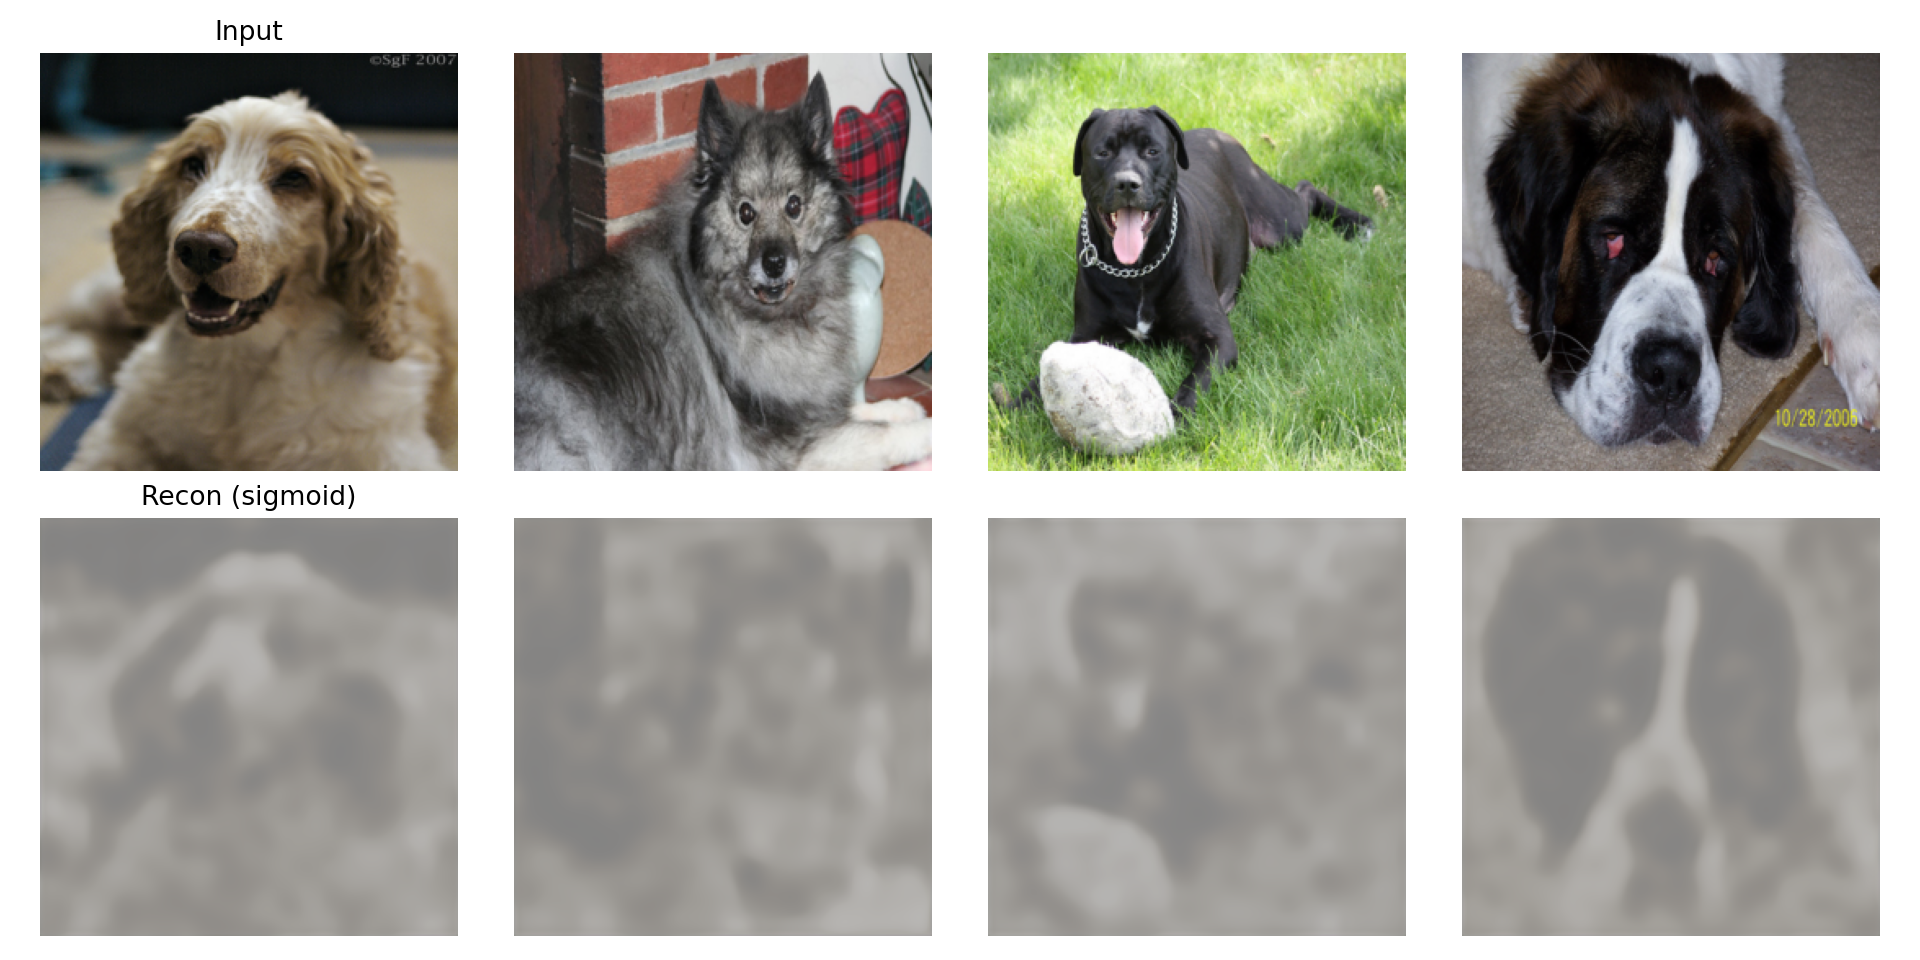

Filename:  /Users/douglasdaly/Documents/GitHub/Generative-AI/results/UNet_v_VAE/vae_latent_walk.png
The reconstructed border image changing with different values of latent encodings. Should vary from one image to another


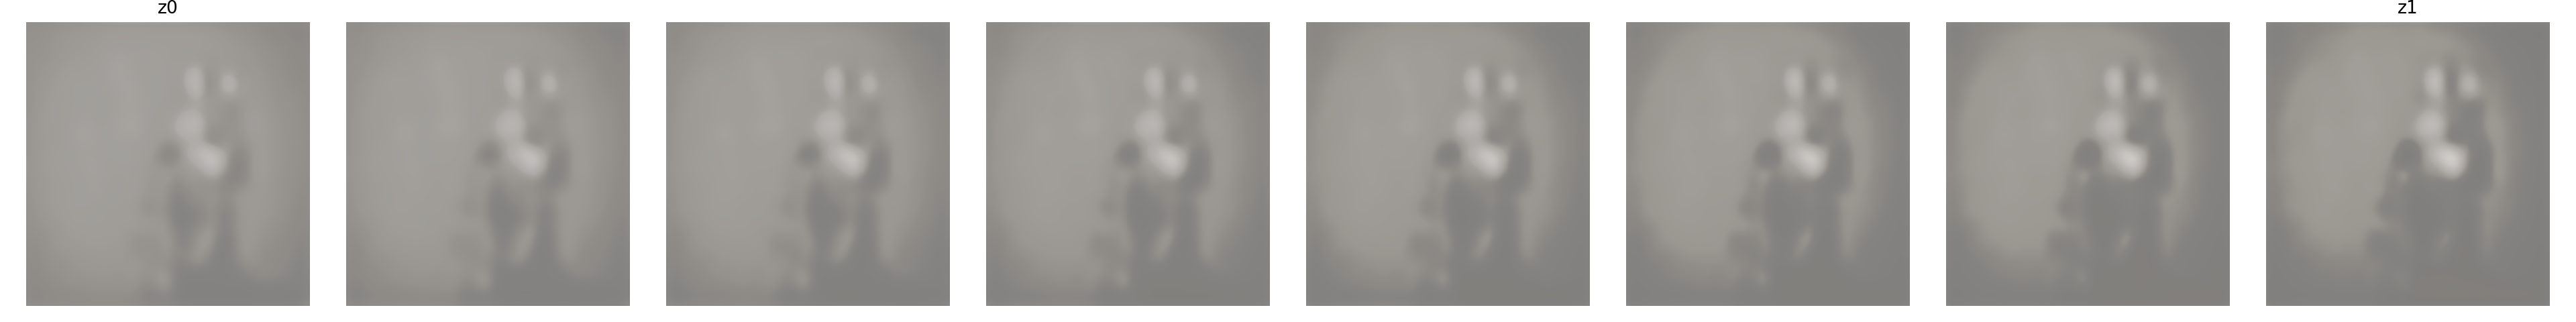

Filename:  /Users/douglasdaly/Documents/GitHub/Generative-AI/results/UNet_v_VAE/unet_progress_final.png
The input image, the ground truth border, predicted border at 0.5, pixel error map (black good, white miss)


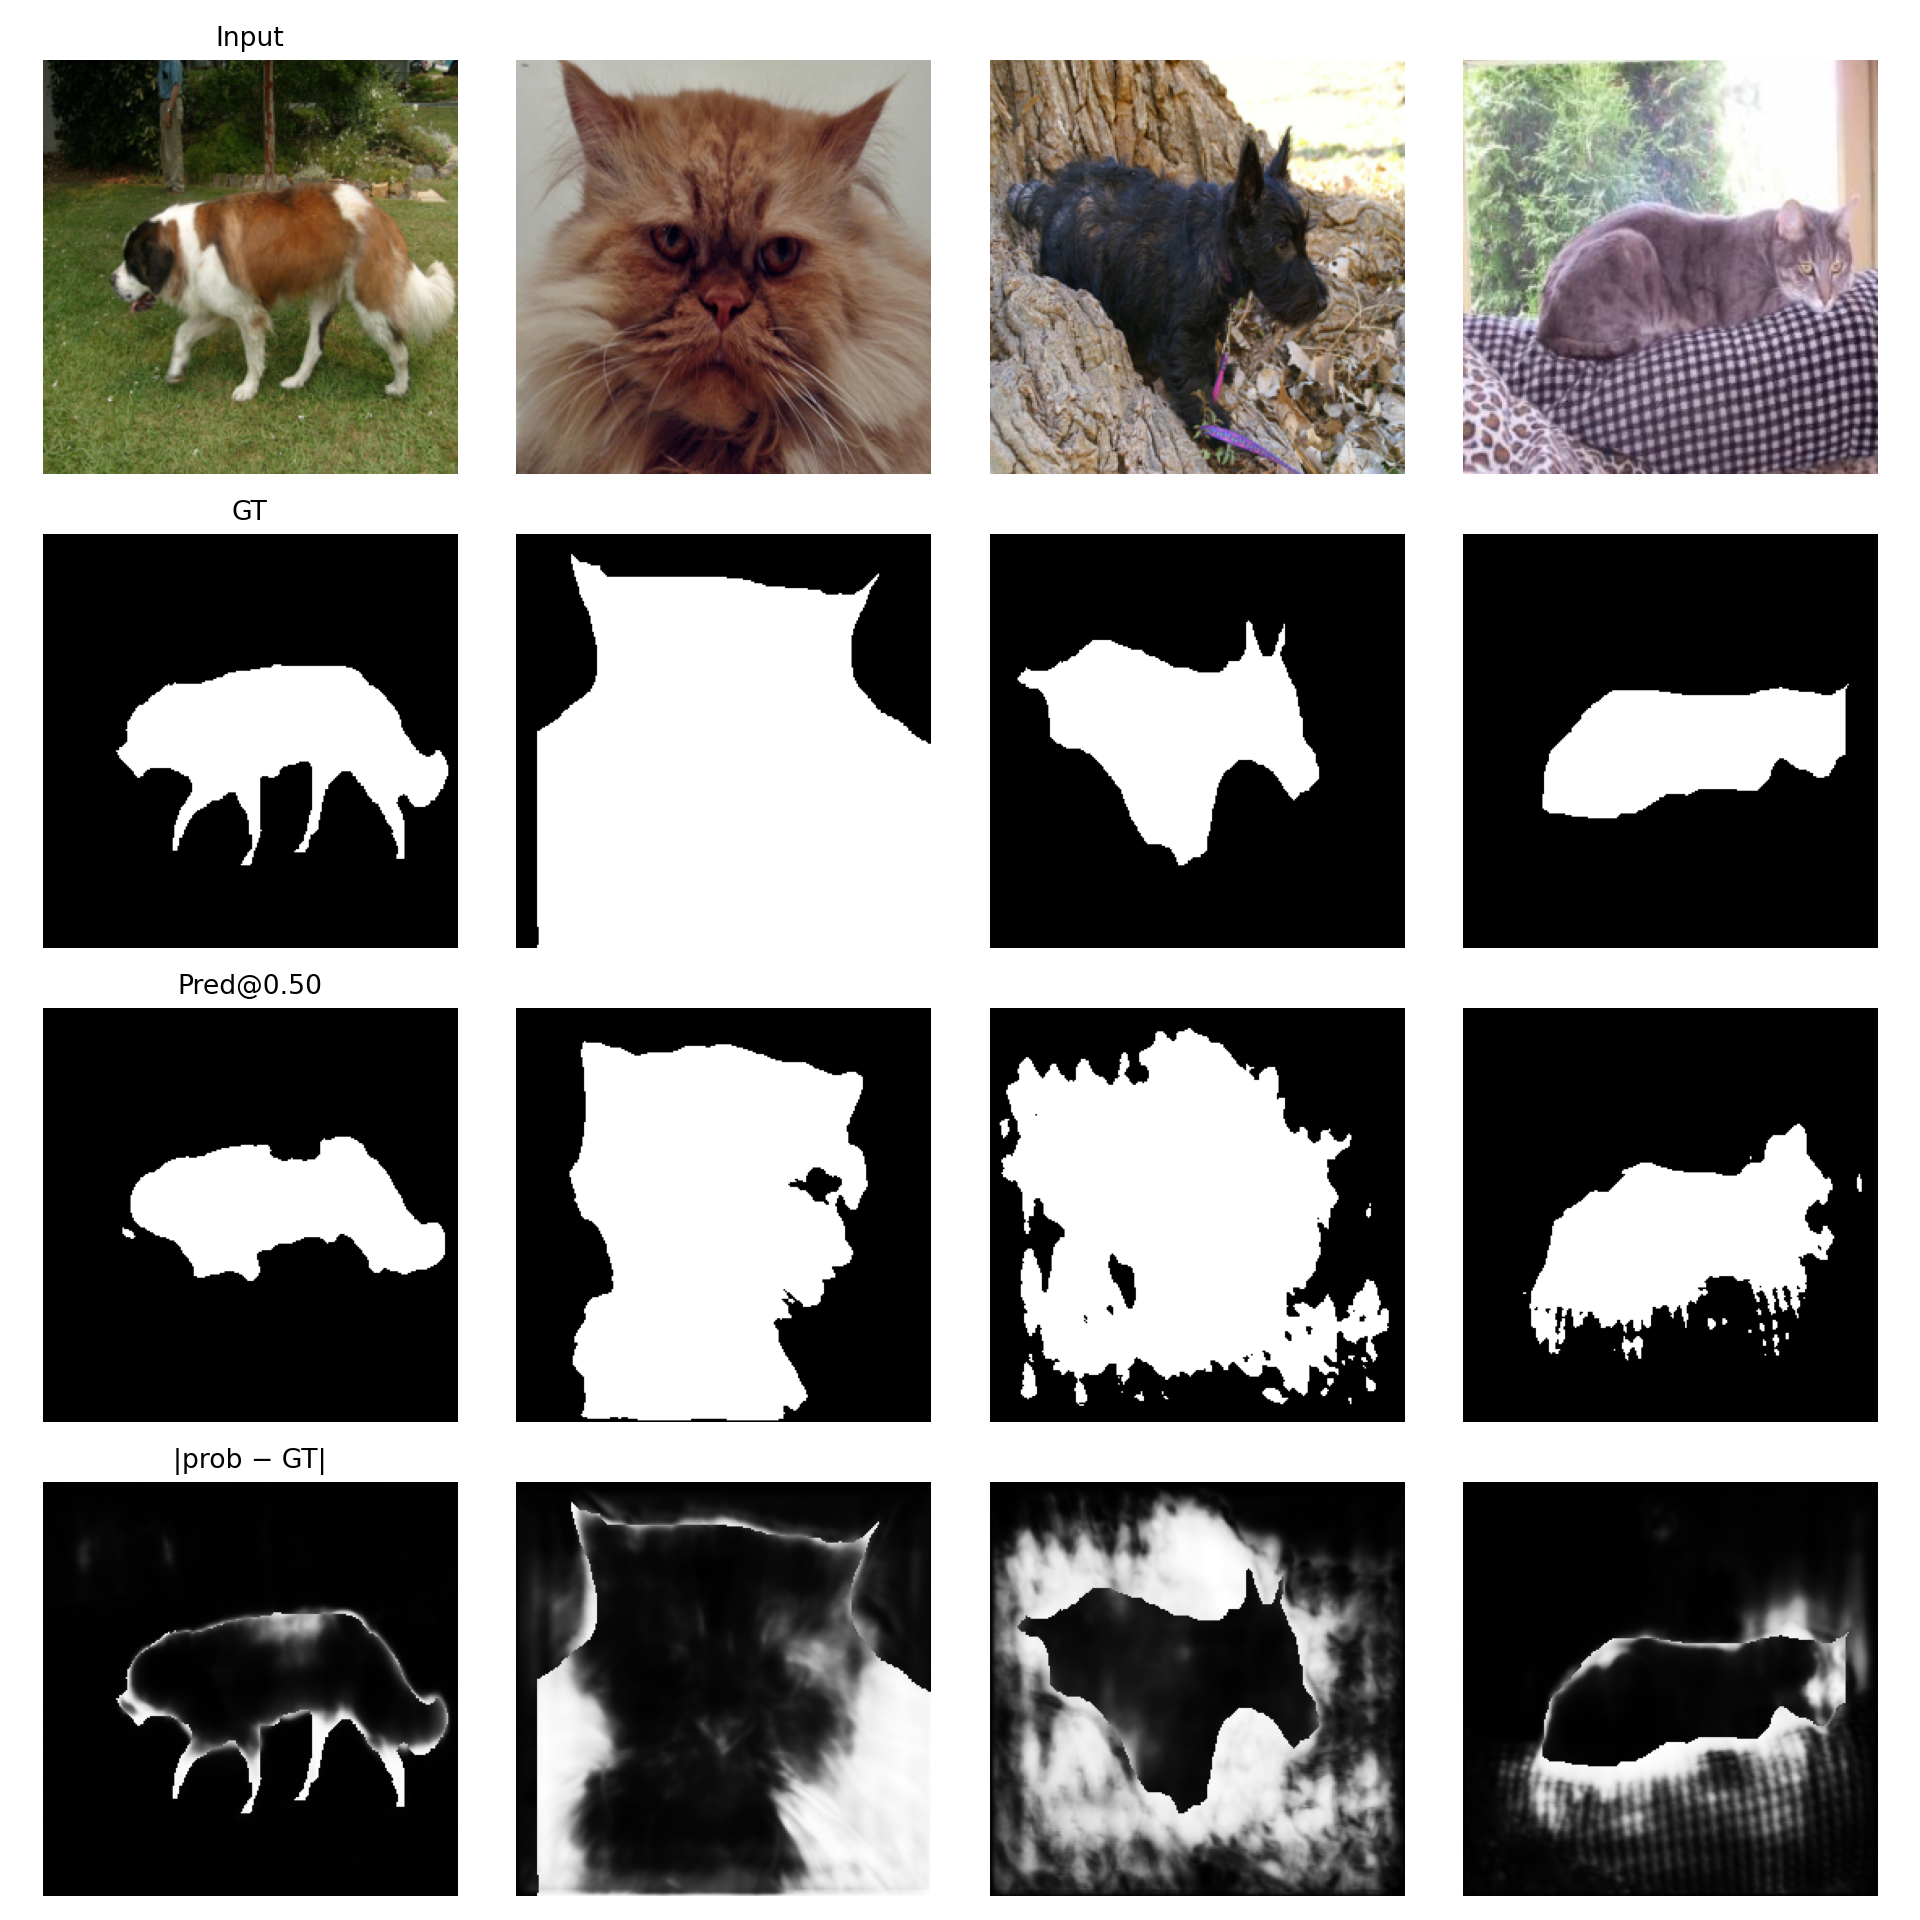

Filename:  /Users/douglasdaly/Documents/GitHub/Generative-AI/results/UNet_v_VAE/iou_vs_threshold_final.png
Shows level of overlap between predicted and actual as function of cutoff threshold


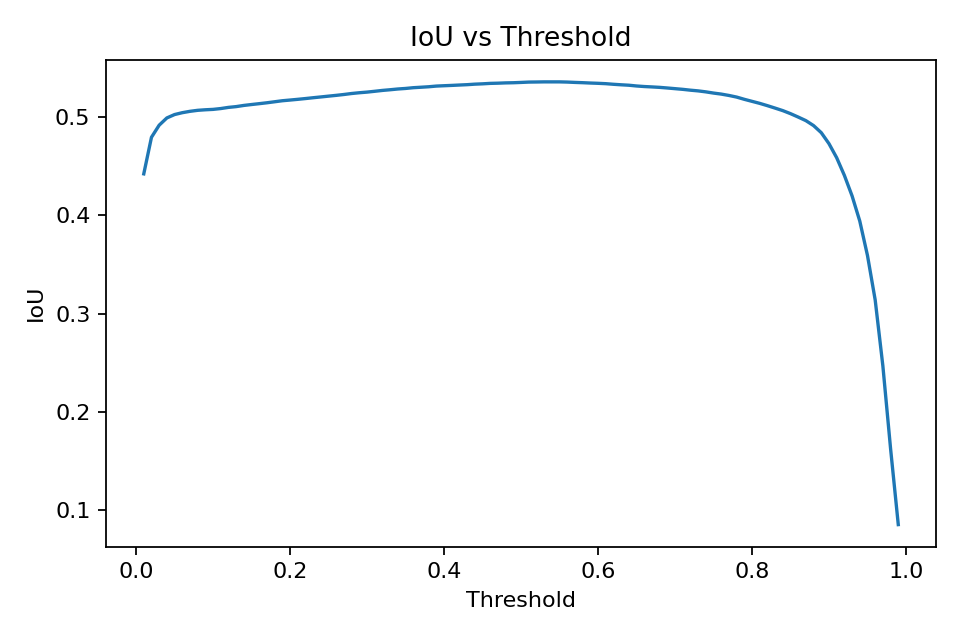

Filename:  /Users/douglasdaly/Documents/GitHub/Generative-AI/results/UNet_v_VAE/summary_sheet.png
Input image, AE/VAE reconstruction, Ground Truth (GT), and the UNet model predicted border at 0.5


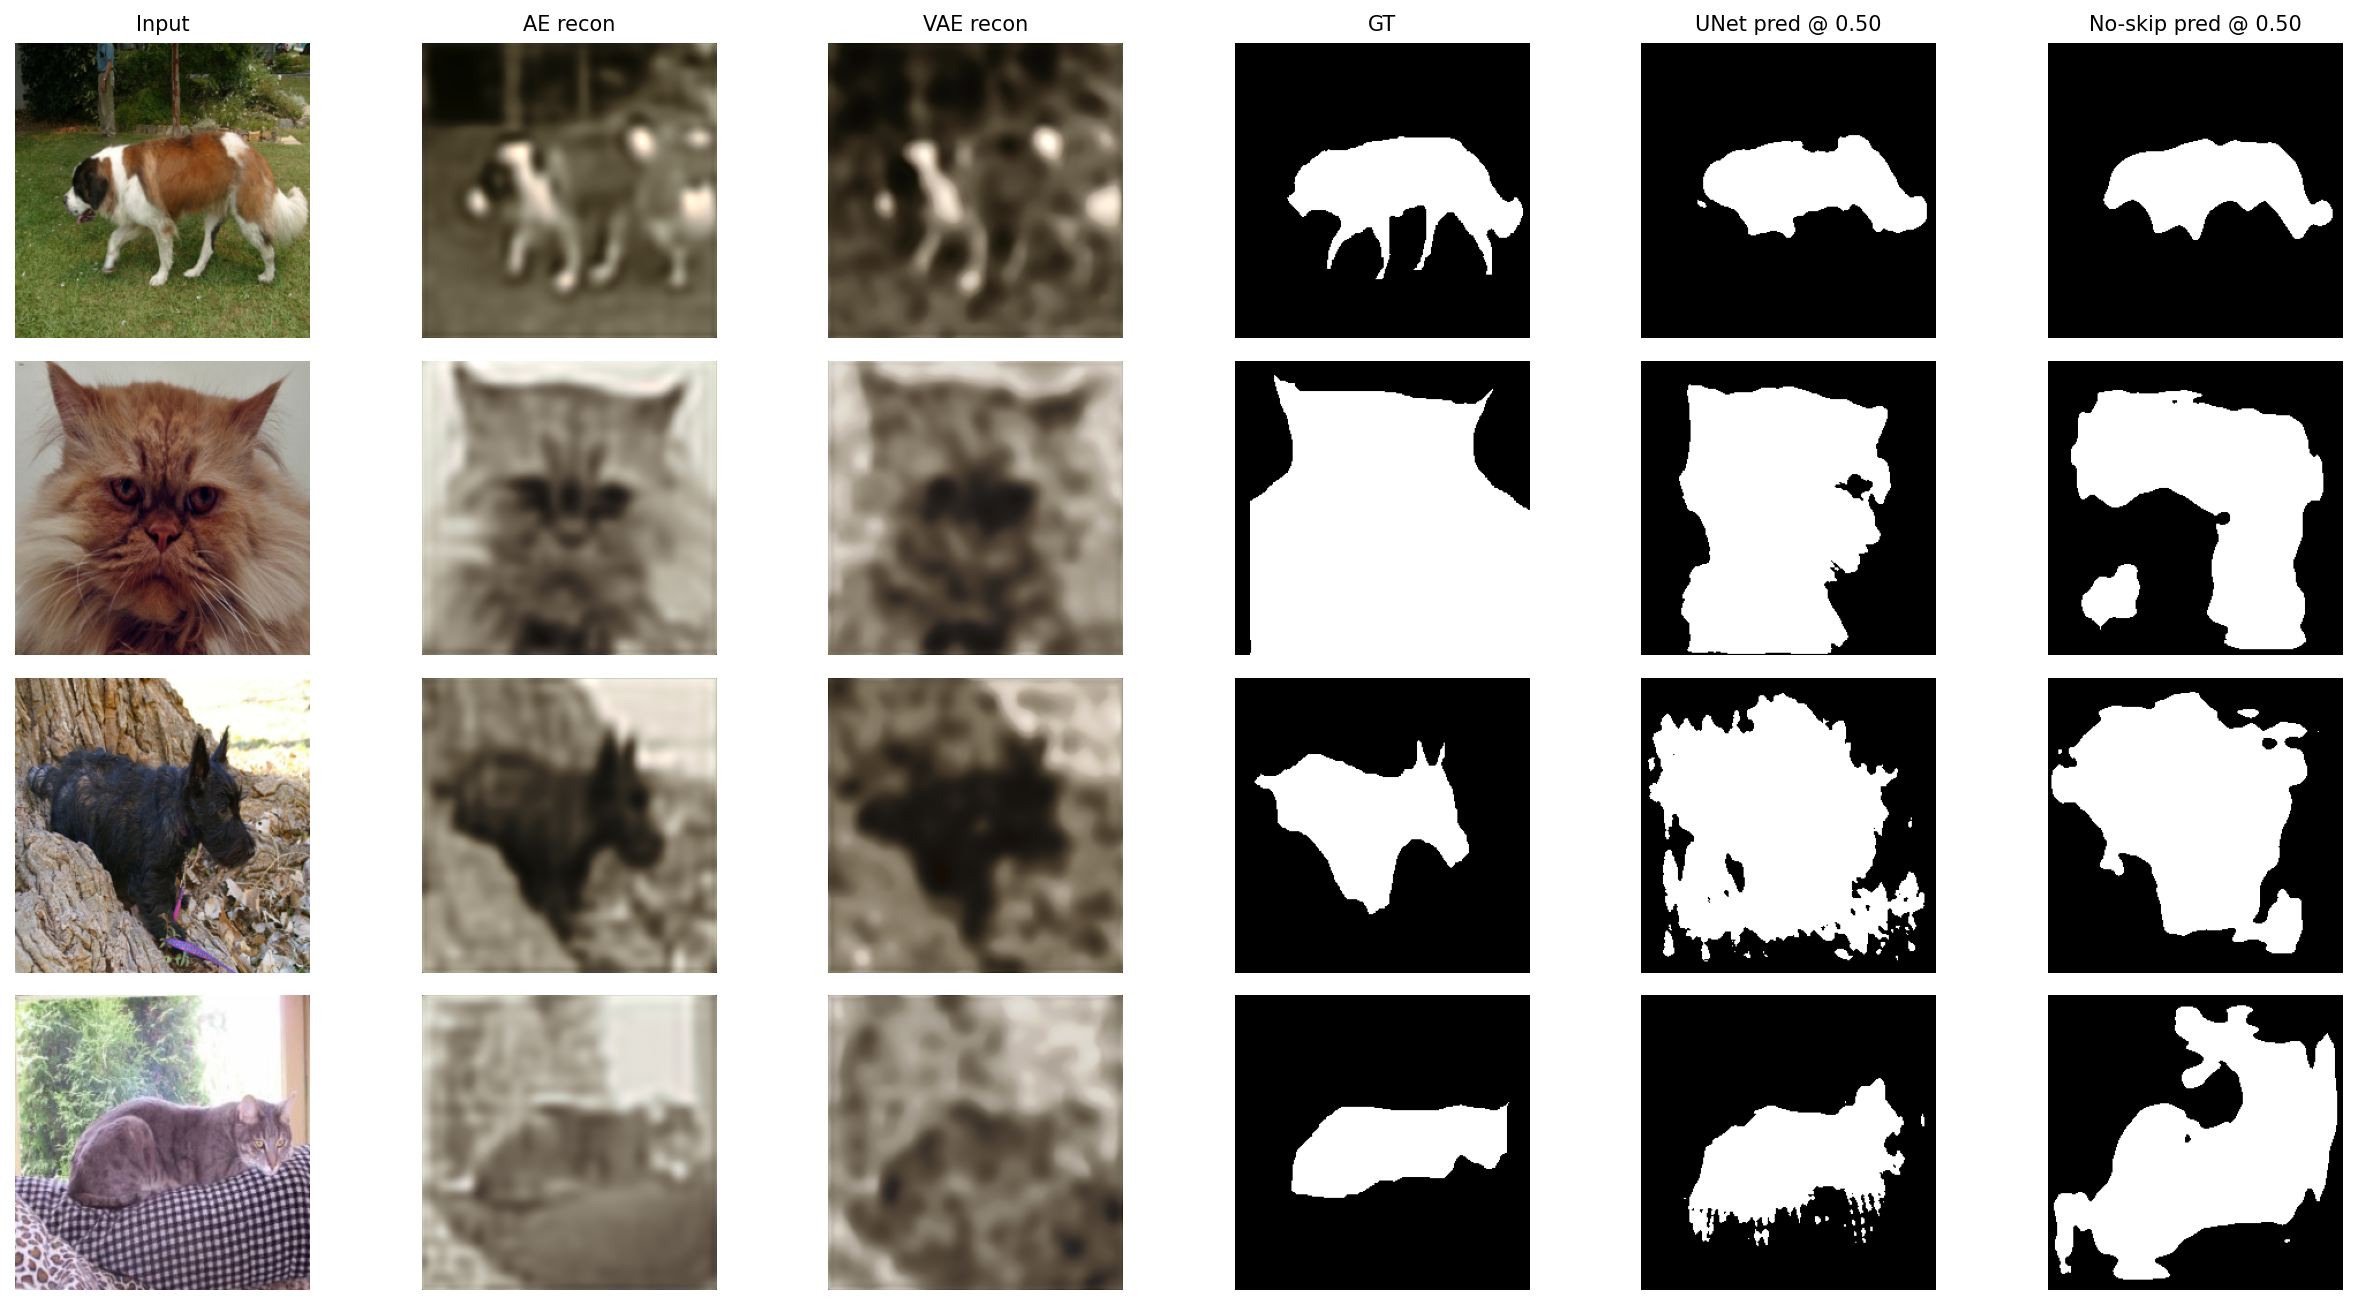

Filename:  /Users/douglasdaly/Documents/GitHub/Generative-AI/results/UNet_v_VAE/noskip_vs_unet.png
Comparison between regular UNet and the no-skip Unet


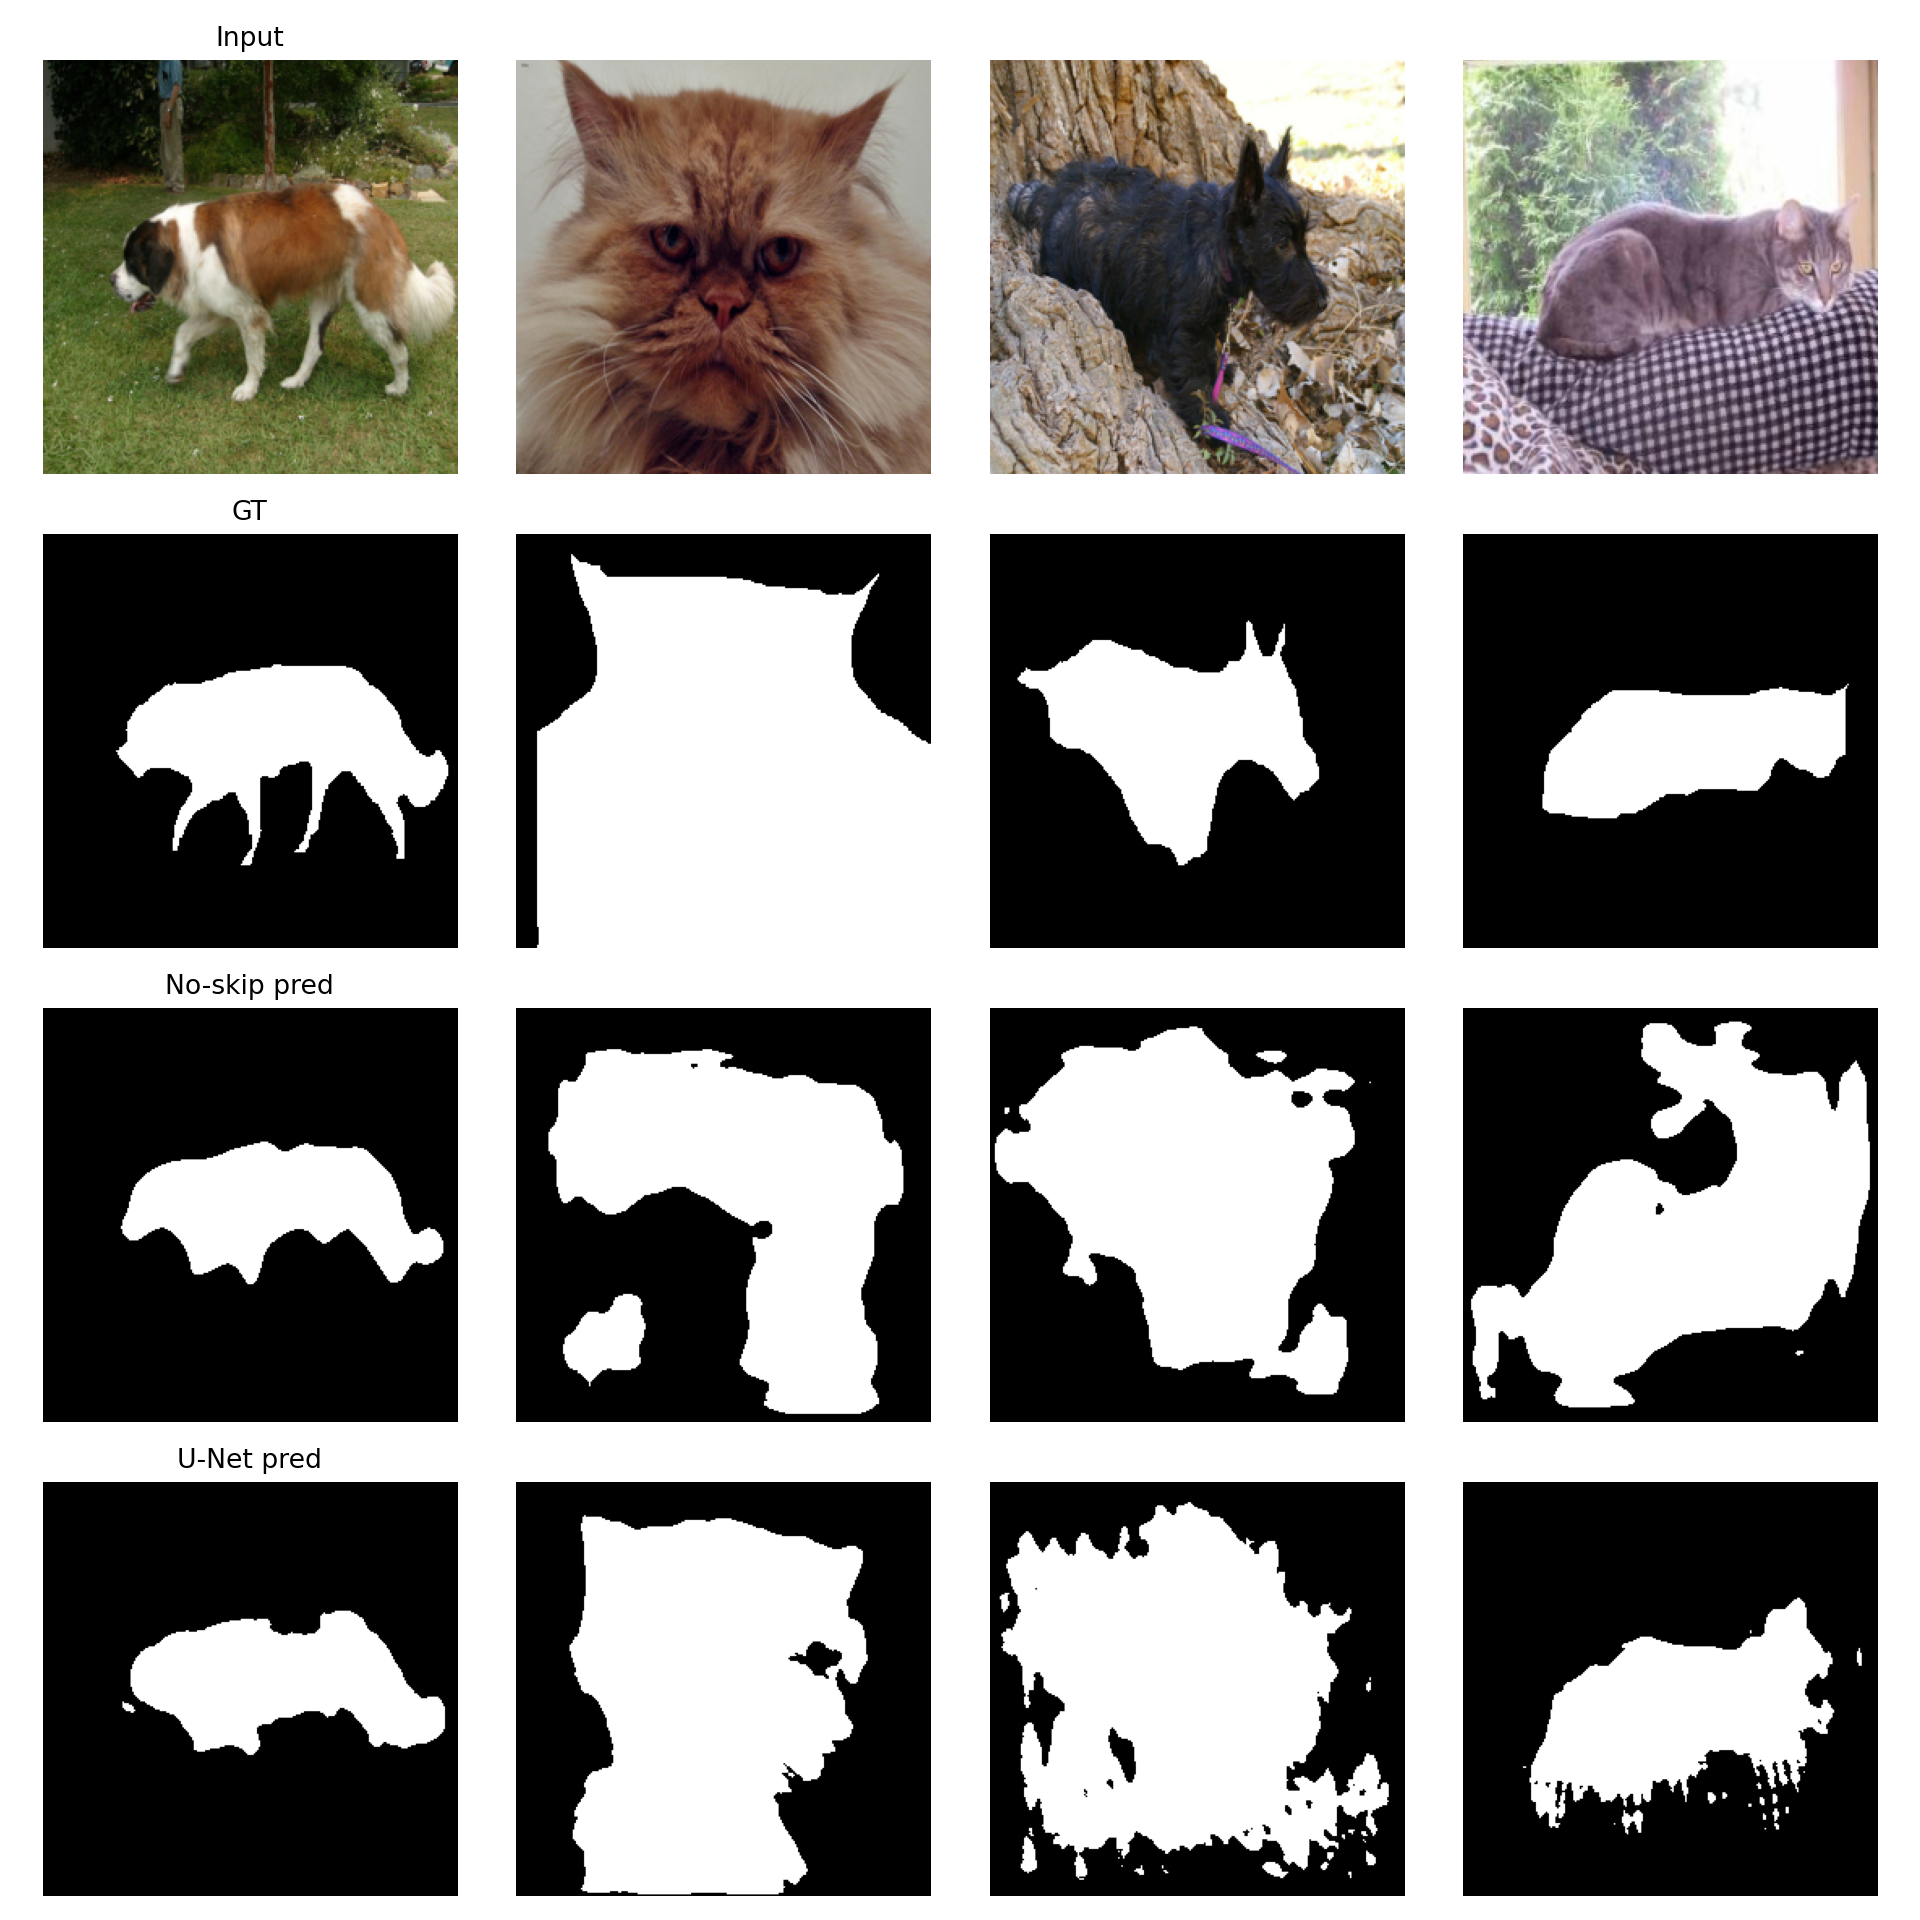

In [47]:
from IPython.display import display, Image
takeaways = {"vae_recon.png": "Input image and estimate of the subject's border.",
             "vae_latent_walk.png": "The reconstructed border image changing with different values of latent encodings. Should vary from one image to another",
             "unet_progress_final.png": "The input image, the ground truth border, predicted border at 0.5, pixel error map (black good, white miss)",
             "iou_vs_threshold_final.png": "Shows level of overlap between predicted and actual as function of cutoff threshold",
             "summary_sheet.png": "Input image, AE/VAE reconstruction, Ground Truth (GT), and the UNet model predicted border at 0.5",
             "noskip_vs_unet.png": "Comparison between regular UNet and the no-skip Unet"}
for img,note in takeaways.items():
    p = result_path + "/" + img
    print("Filename: ",p)
    print(note)
    display(Image(filename=p))


# Class Takeaways — AE vs VAE vs U-Net (with & without skips)

**Big idea:** Same encoder–decoder *bones*; different *heads & wiring* yield different superpowers.



### Reconstruction (AE ↔ VAE)
- **AE:** Deterministic latent `z`; minimizes recon loss (MSE/BCE). Fast, but latent space can be lumpy.
- **VAE:** Learns a **distribution** `q(z|x)`; uses **reparameterization** and **KL(q‖p)** to a prior → smoother, more structured latent space.
- **Why you care:** VAEs generalize better and support **latent walks** (interpolations that stay “on-manifold”).
- **What to show:** AE vs VAE recon row + a **latent walk**; VAE transitions are smoother and semantically coherent.



### Segmentation (No-Skip ↔ U-Net)
- **No-Skip:** Coarse blobs; loses detail when decoding from compressed features.
- **U-Net:** **Skip concatenations** pipe high-res **edges & textures** straight to the decoder → sharper boundaries.
- **Why you care:** Skips buy you **crisp masks** without a massive model.
- **What to show:** Same images, columns: Input → AE → VAE → GT → **U-Net pred** → **No-Skip pred**.
  - Expect U-Net to beat No-Skip on **IoU** (especially ears/whiskers/tails).



### Metrics that matter
- **IoU (Jaccard):** `TP / (TP + FP + FN)` — go-to overlap score.
- **IoU vs Threshold curve:** Single-peaked; pick the **best threshold** (often 0.5–0.7). Don’t lock into 0.5 by faith alone.
- **Dice + BCE (loss):** Dice fights class imbalance; BCE stabilizes logits. Great combo for single-class seg.



### Demo anatomy (what to highlight)
1. **VAE latent walk:** Smooth morphs = “latent space learned structure.”
2. **U-Net vs No-Skip:** Side-by-side masks — U-Net wins on boundaries.
3. **Training curves:** U-Net ramps slower early, then overtakes. No-Skip plateaus first.



### Common gotchas (aka why things look cursed)
- Masks must be **{0,1}** and resized with **nearest** neighbor (never bilinear).
- **Skip concat** must actually concatenate channels (not sum), with correct channel math.
- Small batch? Prefer **GroupNorm** over BatchNorm.
- Head bias: initialize to foreground prior (optional, helps early convergence).



### TL;DR for students
- **VAE**: adds KL + sampling → **structured latent** → better recon & interpolation.  
- **U-Net**: adds **skip-concat** → **sharper masks** and higher IoU than no-skip.  
- Same skeleton, different add-ons; pick the head/wiring for the job.


# Remember this
### VAEs make the latent space behave; U-Nets make the boundaries behave.

# Archive